# 04 — Baseline Citra: MobileNetV2

Tahap 5B. **Belum pernah dijalankan** di mesin penulis kode. Jalankan di mesin
compute.

Replikasi Tabel 1b paper (MobileNetV2 84,5% / 0,82) dan baris IMAGE Tabel 3.

**Prasyarat:** `01_data_audit.ipynb` sudah dijalankan (`manifest.csv` ada) dan
`02_text_features.ipynb` sudah membuat `split_seed*.json`.

Hyperparameter dari paper §4.2: SGD momentum 0,9, lr 0,01, batch 40, **200 epoch**.

> **Peringatan durasi.** MobileNetV2 pada 384x384 selama 200 epoch hampir pasti
> jauh di atas 15 menit. Jalankan sel estimasi dulu, laporkan angkanya, baru
> sepakati budget epoch sebenarnya.

In [1]:
import sys, json, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch

from src import datasets as DS
from src import splits as S
from src import train as T
from src.config import CONFIG, set_seed
from src.utils import save_fig

manifest = pd.read_csv(CONFIG["data_processed"] / "manifest.csv")
labels = manifest["kelas"].tolist()
y = DS.label_indices(labels)
device = T.pick_device()
print(f"{len(manifest)} dokumen | device: {device}")

3482 dokumen | device: cuda


## 1. Data citra

Resize 384x384 **tanpa padding** — aspect ratio sengaja di-warp, sesuai paper.
Grayscale diduplikasi 3 kanal agar bobot ImageNet berlaku.

Tidak ada augmentasi: paper mengukur augmentasi justru sedikit **menurunkan**
akurasi (83,9% dengan vs 84,5% tanpa), karena semua dokumen grayscale dengan
tulisan gelap di latar putih.

In [2]:
from src.models import ImageBranch, build_transform

transform = build_transform()
set_seed(42)
split = S.load_split(42, labels)

def buat_dataset(idx):
    return DS.ImageDataset(manifest["path_citra"].tolist(), y, idx, transform)

loaders = DS.make_loaders(buat_dataset, split, num_workers=CONFIG["num_workers"])
xb, yb = next(iter(loaders["train"]))
print("batch citra:", tuple(xb.shape), "| label:", tuple(yb.shape))
assert xb.shape[1:] == (3, CONFIG["image_size"], CONFIG["image_size"])

batch citra: (8, 3, 384, 384) | label: (8,)


## 2. Estimasi durasi

In [3]:
est = T.estimate_duration(ImageBranch(), loaders, CONFIG["epochs"]["image"],
                          device=device)
print(json.dumps(est, indent=2))
print(f"\nPerkiraan {est['perkiraan_jam']} jam untuk {est['target_epochs']} epoch "
      f"per seed. Dikali 3 seed: {est['perkiraan_jam'] * 3:.1f} jam.")
print("\nKalau ini tidak masuk anggaran, turunkan EPOCHS di sel berikut dan catat "
      "sebagai deviasi eksplisit.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\MATRIX COMPUTER/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:01<00:00, 10.6MB/s]


{
  "detik_per_epoch": 75.525,
  "target_epochs": 200,
  "perkiraan_detik": 15105.0,
  "perkiraan_menit": 251.75,
  "perkiraan_jam": 4.2,
  "device": "cuda"
}

Perkiraan 4.2 jam untuk 200 epoch per seed. Dikali 3 seed: 12.6 jam.

Kalau ini tidak masuk anggaran, turunkan EPOCHS di sel berikut dan catat sebagai deviasi eksplisit.


In [4]:
# Tidak ada yang perlu diatur di sini. Semuanya sudah dipilih otomatis:
# micro-batch dari VRAM, AMP dari jenis device, worker dari sistem operasi,
# epoch dan seed dari ada/tidaknya APDM_CEPAT.
from src.config import deviasi_runtime

EPOCHS = CONFIG["epochs"]["image"]
SEEDS = CONFIG["seeds"]
DEVIASI = deviasi_runtime()

print(f"{EPOCHS} epoch x {len(SEEDS)} seed | batch {CONFIG['batch_size']}"
      + (f" (micro-batch {CONFIG['micro_batch_size']})"
         if CONFIG["micro_batch_size"] else ""))
print("\nDeviasi yang dipaksa mesin ini — SALIN ke catatan eksperimen:")
for d in DEVIASI:
    print(f"  - {d}")
if not DEVIASI:
    print("  tidak ada; setelan persis seperti paper")

200 epoch x 3 seed | batch 40 (micro-batch 8)

Deviasi yang dipaksa mesin ini — SALIN ke catatan eksperimen:
  - batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch
  - mixed precision (AMP) aktif, tidak dipakai paper


## 3. Training

Seluruh jaringan di-fine-tune; backbone **tidak** dibekukan. Paper melakukan
fine-tuning penuh, dan backbone beku akan menjatuhkan akurasi beberapa poin yang
kemudian tersalahartikan sebagai gap replikasi.

In [5]:
def ringkas(nama, hasil_per_seed):
    """Cetak blok siap-salin untuk catatan eksperimen, satu baris per seed."""
    df = pd.DataFrame(hasil_per_seed)
    print(f"=== {nama} ===")
    print(df.to_string(index=False))
    print(f"\nOA       {df['oa'].mean():.4f} +/- {df['oa'].std(ddof=0):.4f}")
    print(f"macro F1 {df['macro_f1'].mean():.4f} +/- {df['macro_f1'].std(ddof=0):.4f}")
    print(f"\nUntuk frontmatter catatan (rata-rata 3 seed):")
    print(f"oa:: {df['oa'].mean():.4f}")
    print(f"macro_f1:: {df['macro_f1'].mean():.4f}")
    print(f"durasi:: {df['durasi_detik'].sum() / 60:.1f} menit total")
    return df

In [6]:
hasil_img, pred_img = [], {}
for seed in SEEDS:
    set_seed(seed)
    sp = S.load_split(seed, labels)
    ld = DS.make_loaders(buat_dataset, sp, num_workers=CONFIG["num_workers"])
    model = ImageBranch(pretrained=True)
    assert all(p.requires_grad for p in model.trunk.parameters())

    print(f"\n[MobileNetV2 seed {seed}]")
    res = T.train_model(
        model, ld, epochs=EPOCHS, device=device,
        log_csv=CONFIG["root"] / "reports" / f"log_IMAGE_seed{seed}.csv",
        ckpt_path=CONFIG["models"] / f"IMAGE_seed{seed}.pt")
    ev = T.evaluate(model, ld["test"], device)

    hasil_img.append({"seed": seed, "oa": round(ev["oa"], 4),
                      "macro_f1": round(ev["macro_f1"], 4),
                      "epoch_terbaik": res["best_epoch"],
                      "epoch_dijalankan": res["epochs_run"],
                      "durasi_detik": res["durasi_detik"]})
    pred_img[seed] = ev

df_img = ringkas("MobileNetV2 (IMAGE)", hasil_img)


[MobileNetV2 seed 42]
  epoch   1/200  train_loss 1.8336  val_oa 0.8000  (70.7s)
  epoch  10/200  train_loss 0.2246  val_oa 0.8000  (74.9s)
  epoch  20/200  train_loss 0.0598  val_oa 0.8500  (75.1s)
  epoch  30/200  train_loss 0.0546  val_oa 0.8625  (74.5s)
  early stopping di epoch 37; terbaik epoch 22

[MobileNetV2 seed 43]
  epoch   1/200  train_loss 1.8815  val_oa 0.5750  (73.2s)
  epoch  10/200  train_loss 0.1860  val_oa 0.8250  (82.0s)
  epoch  20/200  train_loss 0.0698  val_oa 0.8875  (83.1s)
  early stopping di epoch 29; terbaik epoch 14

[MobileNetV2 seed 44]
  epoch   1/200  train_loss 1.8500  val_oa 0.4625  (81.6s)
  epoch  10/200  train_loss 0.2230  val_oa 0.6750  (78.6s)
  epoch  20/200  train_loss 0.0836  val_oa 0.7875  (81.2s)
  early stopping di epoch 26; terbaik epoch 11
=== MobileNetV2 (IMAGE) ===
 seed     oa  macro_f1  epoch_terbaik  epoch_dijalankan  durasi_detik
   42 0.8315    0.8119             22                37      2766.388
   43 0.8136    0.7995          

## 4. Perbandingan dengan paper

OA kita  : 0.8086   paper: 0.845
F1 kita  : 0.7837   paper: 0.82
selisih  : -0.0364

Pembanding lain di Tabel 3 paper: ensemble CNN Harley et al. 79,9%.
MobileNetV2 tunggal mengalahkannya, jadi 84,5% bukan baseline lemah.
               precision    recall  f1-score   support

Advertisement      0.943     0.927     0.934       177
        Email      0.984     0.939     0.961       461
         Form      0.793     0.864     0.827       332
       Letter      0.774     0.895     0.830       437
         Memo      0.920     0.820     0.867       478
         News      0.873     0.952     0.911       145
         Note      0.791     0.806     0.799       155
       Report      0.667     0.520     0.584       204
       Resume      0.808     0.870     0.838        92
   Scientific      0.567     0.567     0.567       201

     accuracy                          0.831      2682
    macro avg      0.812     0.816     0.812      2682
 weighted avg      0.834     0.831     0.830      2682



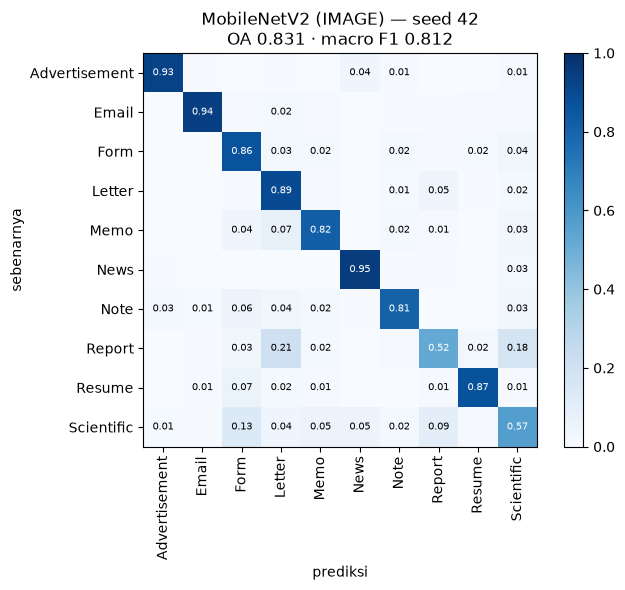

In [7]:
print(f"OA kita  : {df_img['oa'].mean():.4f}   paper: 0.845")
print(f"F1 kita  : {df_img['macro_f1'].mean():.4f}   paper: 0.82")
print(f"selisih  : {df_img['oa'].mean() - 0.845:+.4f}")
print("\nPembanding lain di Tabel 3 paper: ensemble CNN Harley et al. 79,9%.")
print("MobileNetV2 tunggal mengalahkannya, jadi 84,5% bukan baseline lemah.")

fig = T.plot_confusion(pred_img[SEEDS[0]], f"MobileNetV2 (IMAGE) — seed {SEEDS[0]}")
save_fig(fig, f"05_confusion_image_seed{SEEDS[0]}")
print(T.report(pred_img[SEEDS[0]]))

In [8]:
from sklearn.metrics import f1_score

per_kelas = pd.DataFrame(
    {seed: f1_score(e["y_true"], e["y_pred"], average=None,
                    labels=range(len(CONFIG["classes"])), zero_division=0)
     for seed, e in pred_img.items()}, index=CONFIG["classes"])
per_kelas["rata2"] = per_kelas.mean(axis=1)
per_kelas["paper_IMAGE"] = [0.94, 0.96, 0.85, 0.83, 0.90, 0.89, 0.83, 0.61, 0.80, 0.62]
display(per_kelas.round(3))

for seed, e in pred_img.items():
    np.save(CONFIG["data_processed"] / f"pred_image_seed{seed}.npy",
            np.stack([e["y_true"], e["y_pred"]]))
print("\nPrediksi IMAGE per seed disimpan — Tahap 6 membutuhkannya untuk oracle.")

,42,43,44,rata2,paper_IMAGE
Advertisement,0.934,0.871,0.901,0.902,0.94
Email,0.961,0.956,0.947,0.955,0.96
Form,0.827,0.817,0.768,0.804,0.85
Letter,0.830,0.787,0.798,0.805,0.83
Memo,0.867,0.834,0.831,0.844,0.90
News,0.911,0.900,0.858,0.890,0.89
Note,0.799,0.774,0.740,0.771,0.83
Report,0.584,0.660,0.338,0.527,0.61
Resume,0.838,0.802,0.713,0.784,0.80
Scientific,0.567,0.593,0.502,0.554,0.62



Prediksi IMAGE per seed disimpan — Tahap 6 membutuhkannya untuk oracle.


## 5. Pratinjau oracle

Kalau `03_baseline_teks.ipynb` sudah dijalankan pada seed yang sama, oracle bisa
dihitung sekarang: satu sampel benar bila TEXT **atau** IMAGE benar. Ini batas atas
teoretis fusion, dan angkanya menentukan cara membaca hasil Tahap 6.

Paper: TEXT 73,8 / IMAGE 84,5 / FUSION 87,8 / **Oracle 92,1**. Artinya potensi di
atas baseline terbaik 7,6% absolut, dan fusion hanya memanen 3,3% — sekitar 43%.

In [9]:
p_text = CONFIG["data_processed"] / "pred_text_seed42.npy"
p_img = CONFIG["data_processed"] / "pred_image_seed42.npy"

if p_text.exists() and p_img.exists():
    t_true, t_pred = np.load(p_text)
    i_true, i_pred = np.load(p_img)
    assert np.array_equal(t_true, i_true), \
        "urutan test berbeda antara TEXT dan IMAGE — oracle tidak sah"

    oa_t, oa_i = (t_pred == t_true).mean(), (i_pred == i_true).mean()
    # pred_b = IMAGE, baseline yang lebih kuat, dipakai sebagai tie-break
    orc = T.oracle(t_true, t_pred, i_pred)
    print(f"TEXT   {oa_t:.4f}")
    print(f"IMAGE  {oa_i:.4f}")
    print(f"Oracle {orc['oa']:.4f}  (macro F1 {orc['macro_f1']:.4f})")
    print(f"\npotensi di atas baseline terbaik: "
          f"{orc['oa'] - max(oa_t, oa_i):+.4f} absolut")
    print(f"keduanya benar : {orc['keduanya_benar']:.4f}")
    print(f"hanya TEXT     : {orc['hanya_a_benar']:.4f}")
    print(f"hanya IMAGE    : {orc['hanya_b_benar']:.4f}")
    print(f"keduanya salah : {orc['keduanya_salah']:.4f}")
    print("\n'hanya TEXT' adalah ukuran langsung komplementaritas: sampel yang "
          "citra gagal tapi teks berhasil.")
    print("'keduanya salah' adalah bagian yang TIDAK bisa diselamatkan skema "
          "fusion mana pun yang bekerja dengan memilih.")
else:
    print("Jalankan 03_baseline_teks.ipynb dulu untuk menghitung oracle.")

TEXT   0.7345
IMAGE  0.8315
Oracle 0.9098  (macro F1 0.8968)

potensi di atas baseline terbaik: +0.0783 absolut
keduanya benar : 0.6562
hanya TEXT     : 0.0783
hanya IMAGE    : 0.1752
keduanya salah : 0.0902

'hanya TEXT' adalah ukuran langsung komplementaritas: sampel yang citra gagal tapi teks berhasil.
'keduanya salah' adalah bagian yang TIDAK bisa diselamatkan skema fusion mana pun yang bekerja dengan memilih.


In [10]:
print(f"\n----- IMAGE -----")
for _, r in df_img.iterrows():
    print(f"seed {int(r['seed'])}: oa:: {r['oa']}  macro_f1:: {r['macro_f1']}  "
          f"durasi:: {r['durasi_detik']}s")
print(f"rata-rata: oa:: {df_img['oa'].mean():.4f}  "
      f"macro_f1:: {df_img['macro_f1'].mean():.4f}")
print("DEVIASI:", DEVIASI or "tidak ada")


----- IMAGE -----
seed 42: oa:: 0.8315  macro_f1:: 0.8119  durasi:: 2766.388s
seed 43: oa:: 0.8136  macro_f1:: 0.7995  durasi:: 2331.548s
seed 44: oa:: 0.7808  macro_f1:: 0.7397  durasi:: 2109.771s
rata-rata: oa:: 0.8086  macro_f1:: 0.7837
DEVIASI: ['batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch', 'mixed precision (AMP) aktif, tidak dipakai paper']
